# Splitting Datasets for Validation and Testing

In the previous tutorial, we performed a a 3-way split of the curated dataset. However, by partitioning the data this way, we reduce the number of samples which can be used for learning the model, and the results can depend on a particular random choice for the pair of (train, validation) sets.

In this tutorial, we will perform _k_-fold cross validation on the data that we prepared in **Tutorial 1, "Data Curation"**, using the
**[AMPL](https://github.com/ATOMScience-org/AMPL)** modules, classes and functions listed below.

- [parameter_parser](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline-parameter-parser-module)
- [ModelPipeline](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline.model_pipeline.ModelPipeline)
- [split_dataset](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline.model_pipeline.ModelPipeline.split_dataset)
- [compare_splits_plots](https://ampl.readthedocs.io/en/latest/utils.html#module-utils.compare_splits_plots)
- [split_response_dist_plots](https://ampl.readthedocs.io/en/latest/utils.html#module-utils.split_response_dist_plots)

_k_-fold Cross Validation is a statistical resampling technique used to measure the performance of a machine learning model by dividing the dataset into _k_ subsets of equal size (folds).

The model is trained on _k_ − 1 folds and tested on the last fold; unlike the 3-way split, this does not require a validation set. This process is repeated _k_ times, with each fold being used as the test set exactly once. The performance of the model is then averaged over all _k_ iterations to provide a robust estimate of its generalization ability.

This approach can be computationally expensive, but does not waste much data (as is the case when fixing an arbitrary validation set), which is a major advantage for small sample sizes.

In [9]:
import pandas as pd

# Read in data
meas='CellCount'
dir='dn'
dataset_file = f'datasets/training_data/{meas}_hits_{dir}_class_cur.csv'
odir = f'./{meas}_{dir}_class_models'

# Set for less chatty log messages
import logging
logger = logging.getLogger('ATOM')
logger.setLevel(logging.INFO)

## Splitting Methods

**[AMPL](https://github.com/ATOMScience-org/AMPL)** supports a variety of splitting algorithms, including **random** and **scaffold splits**. A **scaffold** is the
core structure of a molecule, with its side chains removed. **Scaffold splits** assign molecules to the training, validation and test sets, so that molecules with the same scaffold group together in the same subset. 
This ensures that compounds in the validation and test sets have different scaffolds from those in the 
training set, and are thus more likely to be structurally different. By contrast, a random split assigns molecules to subsets randomly.

### Rationale for Using Scaffold vs Random Splits

A **scaffold split** is more challenging for model fitting than a **random split**. With a random split, many 
test set compounds may be similar to molecules in the training set, so a model may _appear_ to perform well 
when it is simply "memorizing" training compound structures
associated with different response levels. Such a model will perform badly on molecules that truly are 
different from the training compounds. However, a model trained on molecules that belong to a limited set of scaffold classes has to learn combinations of features that generalize across many chemical families 
to make accurate predictions on compounds with novel scaffolds. A scaffold split provides a way to select 
models with greater generalization ability and assess their performance realistically.


## Performing a Split
We start by constructing a dictionary of parameter values:

In [10]:
df=pd.read_csv(dataset_file)
df.head(2)

,compound_id,base_rdkit_smiles,relation,active
0,SPID236,C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21C,NaN,0.0
1,SPID231,C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21CC,NaN,0.0


In [11]:
params = {
    # dataset info
    "dataset_key" : dataset_file,
    "response_cols" : "active",
    "id_col": "compound_id",
    "smiles_col" : "base_rdkit_smiles",
    "result_dir": odir,

    # splitting
    "previously_split": "False",
    "split_strategy": "k_fold_cv",
    "num_folds": "5", # default is 5
    "splitter": 'scaffold',
 
    # featurization & training params
    "featurizer": "ecfp",
    # "descriptor_type" : "rdkit_raw",
    "previously_featurized": "True",

    "verbose": "True",
}

We parse the `params` dict with the `parameter_parser` module to create a parameter object for input to **[AMPL](https://github.com/ATOMScience-org/AMPL)** functions.

We then create a `ModelPipeline` object and call its `split_dataset` method to do the actual split.

> **Note**: 
             `split_dataset()` can also featurize the dataset; we will explore featurization in a later tutorial. For now, we provide prefeaturized data in the `./dataset/scaled_descriptors` folder. 

In [12]:
from atomsci.ddm.pipeline import model_pipeline as mp
from atomsci.ddm.pipeline import parameter_parser as parse

pparams = parse.wrapper(params)
MP = mp.ModelPipeline(pparams)
split_uuid = MP.split_dataset()

/Users/echun/repos/atomsci/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/echun/repos/atomsci/lib/python3.9/site-packages/deepchem/feat/smiles_tokenizer.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Skipped loading some Jax models, missing a dependency. No module named 'jax'
INFO:ATOM:Initiating ModelPipeline with seed 2949340984
INFO:ATOM:Featurized dataset not previously saved for dataset CellCount_hits_dn_class_cur, creating new
INFO:ATOM:Featurizing sample 0
INFO:ATOM:Dataset split table saved to /Users/echun/repos/DILI-rotation/AMPL_models/datasets/training_data/CellCoun

The dataset split table is saved as a .csv in the same directory as the `dataset_key`. 
The name of the split file starts with the `dataset_key` and is followed by the `split_strategy` (k_fold_cv), `split type` (scaffold), and the `split_uuid` (a unique identifier of the split).

In [13]:
# display the split file location
import glob
import os
dirname = os.path.dirname(params['dataset_key'])
split_file = glob.glob(f"{dirname}/*{split_uuid}*")[0]
split_file

'datasets/training_data/CellCount_hits_dn_class_cur_5_fold_cv_scaffold_f203283d-5ba0-4912-b868-d3e3fd7db4fb.csv'

## Format of the Split File
The split file consists of three columns: `cmpd_id` is the compound ID; `subset` tells you if the compound is in the train, validation, or test set and `fold` contains the fold index, which is used only by _k_-fold cross-validation splits.

In [19]:
# Explore contents of the split file
split_df = pd.read_csv(split_file)
split_df.head()

,cmpd_id,subset,fold
0,SPID236,train_valid,0
1,SPID231,train_valid,0
2,SPID339,train_valid,0
3,SPID504,train_valid,0
4,SPID262,train_valid,0


In [20]:
# Show the numbers of compounds in each split subset
split_df.subset.value_counts()

subset
train_valid    519
test            58
Name: count, dtype: int64

In [22]:
# Show the numbers of compounds in each fold by subset
split_df.groupby(['subset', 'fold']).size()

subset       fold
test         0        58
train_valid  0       103
             1       104
             2       104
             3       104
             4       104
dtype: int64

## Visualizing Scaffold Splits
**[Tanimoto distance](https://en.wikipedia.org/wiki/Jaccard_index#Tanimoto_similarity_and_distance)** is a handy way 
to measure structural dissimilarity between compounds represented using **[ECFP fingerprints](https://pubs.acs.org/doi/10.1021/ci100050t)**. 

For _k_-fold cross validation, you would ideally visualize the Tanimoto distance distribution for each fold separately to confirm that scaffold splitting is creating structurally diverse splits across folds. However, the Tanimoto distance visualization in compare_splits_plots currently supports train_valid_test splits only. For now, we can use fold 0 as a representative example. 

We can use functions in the `compare_splits_plots` module to compute **[Tanimoto distance](https://en.wikipedia.org/wiki/Jaccard_index#Tanimoto_similarity_and_distance)** between each test set compound and its nearest neighbor in the training set, and then plot the distribution of distances for each subset. 

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import atomsci.ddm.utils.compare_splits_plots as csp

# read the dataset
df = pd.read_csv(dataset_file)

# read the split file
split = pd.read_csv(split_file)
split_type = params['splitter']

In [27]:
# grab fold 0 as a representative single split
fold0 = split[split['fold'] == 0].copy()

# rename train_valid to train for SplitStats compatibility
fold0['subset'] = fold0['subset'].replace('train_valid', 'train')

# now pass fold0 to create SplitStats
ss = csp.SplitStats(df, fold0, smiles_col='base_rdkit_smiles', id_col='compound_id', response_cols=['active'])

Text(0.5, 1.0, 'Train vs Test Tanimoto Dist using scaffold split')

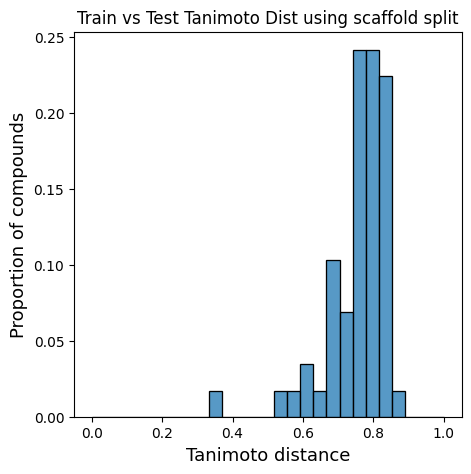

In [29]:
# plot
fig, ax = plt.subplots(figsize=(5,5))
ss.dist_hist_train_v_test_plot(ax=ax)
ax.set_title(f"Train vs Test Tanimoto Dist using {split_type} split")

Again, in _k_-fold cross validation, there is no separate validation set. As a result, the Train vs Valid plot is not meaningful here.

The majority of compounds have **[Tanimoto distances](https://en.wikipedia.org/wiki/Jaccard_index#Tanimoto_similarity_and_distance)** between 0.2 and 0.8 from the training set, indicating that they are structurally different from the training compounds. This suggests that scaffold splitting is creating structurally diverse test sets as expected.

We can also plot the distributions of the response values - the $pK_i$'s - in each subset. These plots can
be useful in diagnosing model performance problems; if the response distributions in the training and test sets
are dramatically different, it may be hard to train a model that performs well on the test set.

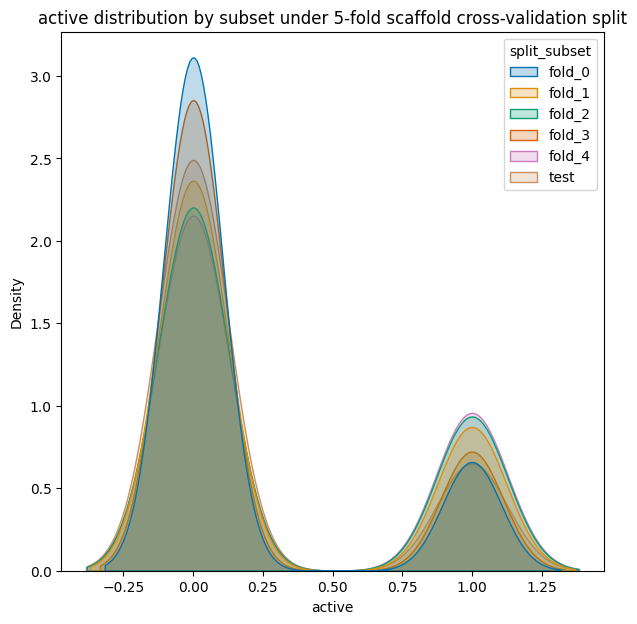

In [32]:
import atomsci.ddm.utils.split_response_dist_plots as srdp
split_params = {
    "dataset_key" : dataset_file,
    "smiles_col" : "base_rdkit_smiles",
    "response_cols" : "active",
    "split_uuid": split_uuid,
    "split_strategy": "k_fold_cv",
    "splitter": 'scaffold',
}
srdp.plot_split_subset_response_distrs(split_params)

For this dataset, the $pK_i$'s have roughly similar distributions across the **scaffold split** subsets, except that the training set has slightly more compounds with large values.

In **Tutorial 3, "Train a Simple Regression Model"**, we will use this dataset and **scaffold split** to train a model to predict the $pK_i$'s.

If you have specific feedback about a tutorial, please complete the **[AMPL Tutorial Evaluation](https://forms.gle/pa9sHj4MHbS5zG7A6)**.